In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import os
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")

Kullanılan Cihaz: cuda


In [ ]:
data_dir = r'C:\Users\efeya\Desktop\DerinFinal\Data\archive' 

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'test']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True)
              for x in ['train', 'test']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes
print(f"Sınıflar: {class_names} | Eğitim boyutu: {dataset_sizes['train']}")

Sınıflar: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise'] | Eğitim boyutu: 28709


In [ ]:
model = models.shufflenet_v2_x1_0(pretrained=True)

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.1, verbose=True)

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        val_loss_for_scheduler = 0.0

        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                val_loss_for_scheduler = epoch_loss

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: %{epoch_acc*100:.2f}')

        scheduler.step(val_loss_for_scheduler)

    model.load_state_dict(best_model_wts)
    return model

model = train_model(model, criterion, optimizer, scheduler, num_epochs=15)


Epoch 1/15
----------
train Loss: 1.1255 Acc: %57.58
test Loss: 1.0960 Acc: %58.48

Epoch 2/15
----------
train Loss: 1.0239 Acc: %61.50
test Loss: 1.0100 Acc: %61.81

Epoch 3/15
----------
train Loss: 0.9686 Acc: %63.49
test Loss: 0.9714 Acc: %63.67

Epoch 4/15
----------
train Loss: 0.9261 Acc: %65.29
test Loss: 0.9330 Acc: %65.00

Epoch 5/15
----------
train Loss: 0.8906 Acc: %66.38
test Loss: 0.9408 Acc: %65.21

Epoch 6/15
----------
train Loss: 0.8641 Acc: %67.68
test Loss: 0.9194 Acc: %66.22

Epoch 7/15
----------
train Loss: 0.8366 Acc: %68.84
test Loss: 0.9193 Acc: %65.60

Epoch 8/15
----------
train Loss: 0.8052 Acc: %70.08
test Loss: 0.9141 Acc: %66.51

Epoch 9/15
----------
train Loss: 0.7796 Acc: %70.40
test Loss: 0.9020 Acc: %66.91

Epoch 10/15
----------
train Loss: 0.7605 Acc: %71.68
test Loss: 0.9216 Acc: %67.12

Epoch 11/15
----------
train Loss: 0.7391 Acc: %72.31
test Loss: 0.9114 Acc: %67.16

Epoch 12/15
----------
train Loss: 0.7147 Acc: %73.23
test Loss: 0.9209 A

In [ ]:
import torch.optim as optim

for param in model.parameters():
    param.requires_grad = True

fine_tune_lr = 1e-5 

optimizer_ft = optim.Adam(model.parameters(), lr=fine_tune_lr)

scheduler_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ft, 
    mode='min', 
    patience=3, 
    factor=0.1, 
    verbose=True
)

print("Fine-Tuning Aşaması Başlıyor...")
model = train_model(
    model, 
    criterion, 
    optimizer_ft, 
    scheduler_ft, 
    num_epochs=10
)

print("Eğitim Tamamlandı! En iyi model yüklendi.")

Fine-Tuning Aşaması Başlıyor...

Epoch 1/10
----------
train Loss: 0.5500 Acc: %79.77
test Loss: 0.8847 Acc: %69.52

Epoch 2/10
----------
train Loss: 0.5417 Acc: %80.15
test Loss: 0.8823 Acc: %69.48

Epoch 3/10
----------
train Loss: 0.5370 Acc: %80.44
test Loss: 0.8859 Acc: %69.63

Epoch 4/10
----------
train Loss: 0.5310 Acc: %80.35
test Loss: 0.8860 Acc: %69.50

Epoch 5/10
----------
train Loss: 0.5280 Acc: %80.58
test Loss: 0.8993 Acc: %69.38

Epoch 6/10
----------
train Loss: 0.5283 Acc: %80.67
test Loss: 0.8958 Acc: %69.63

Epoch 7/10
----------
train Loss: 0.5223 Acc: %80.87
test Loss: 0.9036 Acc: %69.27

Epoch 8/10
----------
train Loss: 0.5215 Acc: %80.77
test Loss: 0.8989 Acc: %69.64

Epoch 9/10
----------
train Loss: 0.5161 Acc: %81.22
test Loss: 0.8981 Acc: %69.66

Epoch 10/10
----------
train Loss: 0.5224 Acc: %80.66
test Loss: 0.9001 Acc: %69.63
Eğitim Tamamlandı! En iyi model yüklendi.


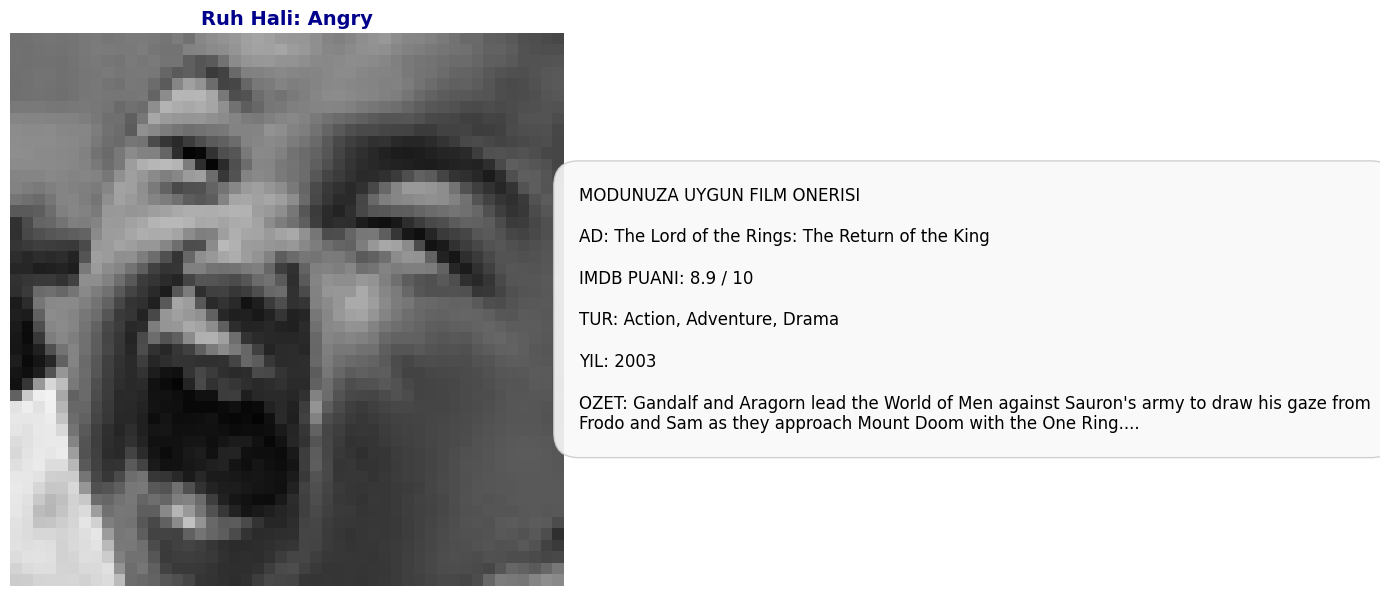

In [ ]:
import torch
from torchvision import transforms
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
classes = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

val_transforms = transforms.Compose([
    transforms.Resize((48, 48)), 
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def predict_and_recommend(image_path):
    img = Image.open(image_path).convert('RGB')
    input_tensor = val_transforms(img).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)
        predicted_emotion = classes[pred[0]]
    
    emotion_to_genre = {
        'Happy': 'Comedy|Animation|Adventure', 
        'Sad': 'Drama|Romance',                
        'Angry': 'Action|Crime|Thriller',             
        'Fear': 'Horror|Thriller',              
        'Disgust': 'Documentary|History',            
        'Surprise': 'Sci-Fi|Fantasy|Mystery',   
        'Neutral': 'Drama|Adventure'      
    }
    target_genre = emotion_to_genre.get(predicted_emotion, 'Drama')
    filtered = imdb_df[imdb_df['Genre'].str.contains(target_genre, case=False, na=False)]
    
    movie = filtered.sort_values(by='IMDB_Rating', ascending=False).head(10).sample(n=1).iloc[0]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1, 1.2]})
    
    ax1.imshow(img)
    ax1.set_title(f"Ruh Hali: {predicted_emotion}", fontsize=14, fontweight='bold', color='darkblue')
    ax1.axis('off')

    ax2.axis('off')
    info_text = (
        f"MODUNUZA UYGUN FILM ONERISI\n\n"
        f"AD: {movie['Series_Title']}\n\n"
        f"IMDB PUANI: {movie['IMDB_Rating']} / 10\n\n"
        f"TUR: {movie['Genre']}\n\n"
        f"YIL: {movie['Released_Year']}\n\n"
        f"OZET: {movie['Overview'][:300]}..."
    )
    
    ax2.text(0, 0.5, info_text, fontsize=12, va='center', ha='left', wrap=True,
             bbox=dict(boxstyle="round,pad=1.5", facecolor='#f9f9f9', edgecolor='#cccccc', alpha=0.9))

    plt.tight_layout()
    plt.show()

test_resmi = r'C:\Users\efeya\Desktop\DerinFinal\Data\archive\test\fear\PrivateTest_134207.jpg'
predict_and_recommend(test_resmi)

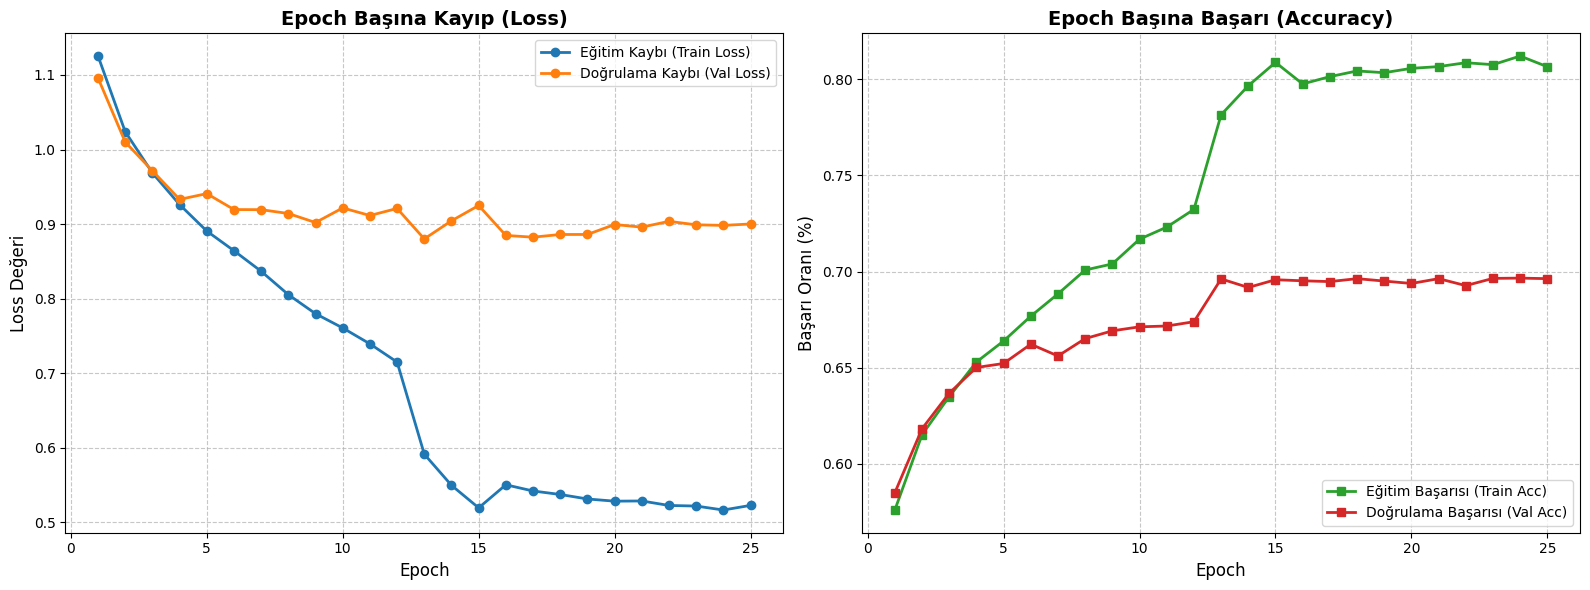

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    epochs_range = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, history['train_loss'], label='Eğitim Kaybı (Train Loss)', color='#1f77b4', marker='o', linewidth=2)
    plt.plot(epochs_range, history['val_loss'], label='Doğrulama Kaybı (Val Loss)', color='#ff7f0e', marker='o', linewidth=2)
    plt.title('Epoch Başına Kayıp (Loss)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss Değeri', fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, history['train_acc'], label='Eğitim Başarısı (Train Acc)', color='#2ca02c', marker='s', linewidth=2)
    plt.plot(epochs_range, history['val_acc'], label='Doğrulama Başarısı (Val Acc)', color='#d62728', marker='s', linewidth=2)
    plt.title('Epoch Başına Başarı (Accuracy)', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Başarı Oranı (%)', fontsize=12)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

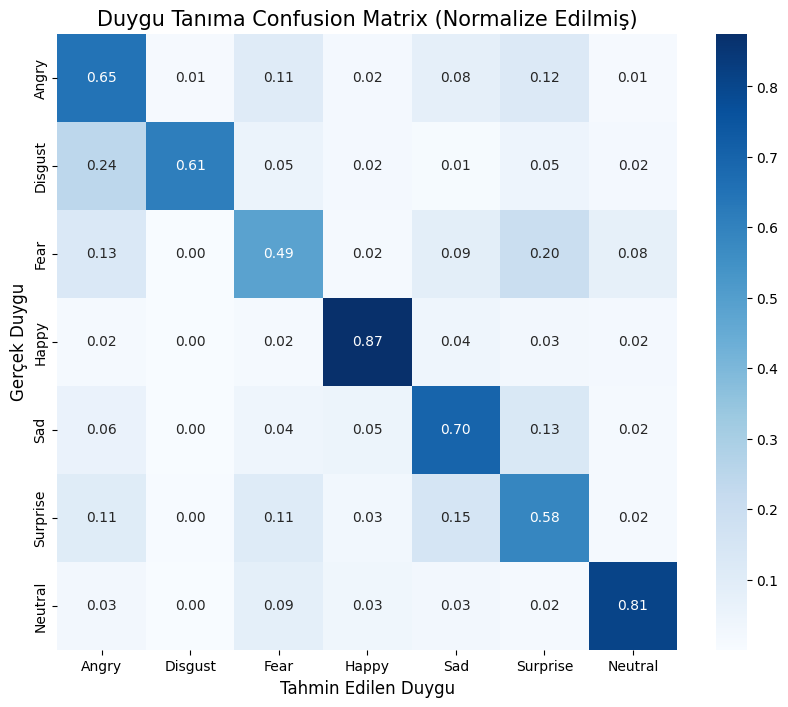


--- Sınıflandırma Raporu ---
              precision    recall  f1-score   support

       Angry       0.60      0.65      0.62       958
     Disgust       0.76      0.61      0.68       111
        Fear       0.55      0.49      0.52      1024
       Happy       0.91      0.87      0.89      1774
         Sad       0.65      0.70      0.67      1233
    Surprise       0.57      0.58      0.58      1247
     Neutral       0.80      0.81      0.80       831

    accuracy                           0.70      7178
   macro avg       0.69      0.67      0.68      7178
weighted avg       0.70      0.70      0.70      7178



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

def plot_confusion_matrix(model, dataloader, classes):
    all_preds = []
    all_labels = []
    
    model.eval()
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_perc, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    
    plt.title('Duygu Tanıma Confusion Matrix (Normalize Edilmiş)', fontsize=15)
    plt.xlabel('Tahmin Edilen Duygu', fontsize=12)
    plt.ylabel('Gerçek Duygu', fontsize=12)
    plt.show()

    print("\n--- Sınıflandırma Raporu ---")
    print(classification_report(all_labels, all_preds, target_names=classes))

plot_confusion_matrix(model, dataloaders['test'], classes)

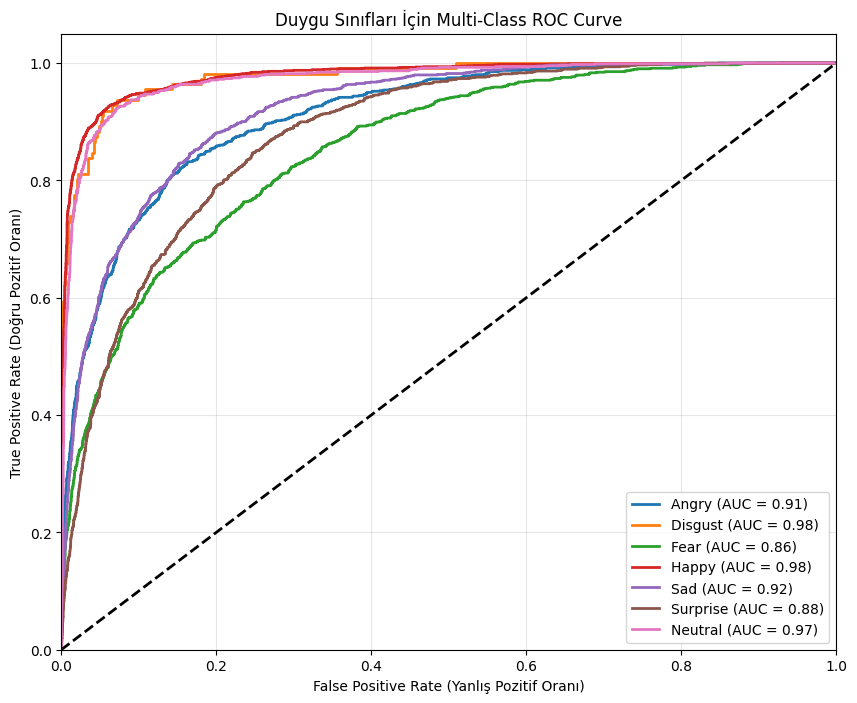

In [ ]:
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_curve(model, dataloader, classes):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            
            probs = F.softmax(outputs, dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    n_classes = len(classes)

    y_test = label_binarize(all_labels, classes=range(n_classes))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    plt.figure(figsize=(10, 8))

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test[:, i], all_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
        plt.plot(fpr[i], tpr[i], lw=2, 
                 label=f'{classes[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
    plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
    plt.title('Duygu Sınıfları İçin Multi-Class ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

plot_roc_curve(model, dataloaders['test'], classes)